In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [5]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

path = "default_rates.csv"

df = pd.read_csv(path)
print(df.shape)
print(df.head)

(35, 2)
<bound method NDFrame.head of     fyear  default_rate
0    1990      0.000000
1    1991      0.003953
2    1992      0.000000
3    1993      0.000000
4    1994      0.001582
5    1995      0.002649
6    1996      0.000000
7    1997      0.011707
8    1998      0.033363
9    1999      0.032013
10   2000      0.055099
11   2001      0.033442
12   2002      0.017828
13   2003      0.011914
14   2004      0.008621
15   2005      0.003891
16   2006      0.006221
17   2007      0.013492
18   2008      0.035772
19   2009      0.005858
20   2010      0.006656
21   2011      0.008170
22   2012      0.001605
23   2013      0.005477
24   2014      0.024463
25   2015      0.020164
26   2016      0.008340
27   2017      0.005339
28   2018      0.013087
29   2019      0.026066
30   2020      0.000791
31   2021      0.006015
32   2022      0.011450
33   2023      0.004695
34   2024      0.001610>


In [6]:
#step 1
years = df["fyear"].values
obs = df["default_rate"].values

mean_obs = np.mean(obs)
std_obs = np.std(obs, ddof=1)

print("Observed mean default rate (PD):", mean_obs)
print("Observed std of default rate:", std_obs)
print("Number of periods T:", len(obs))

Observed mean default rate (PD): 0.012038117996733749
Observed std of default rate: 0.013011569492983625
Number of periods T: 35


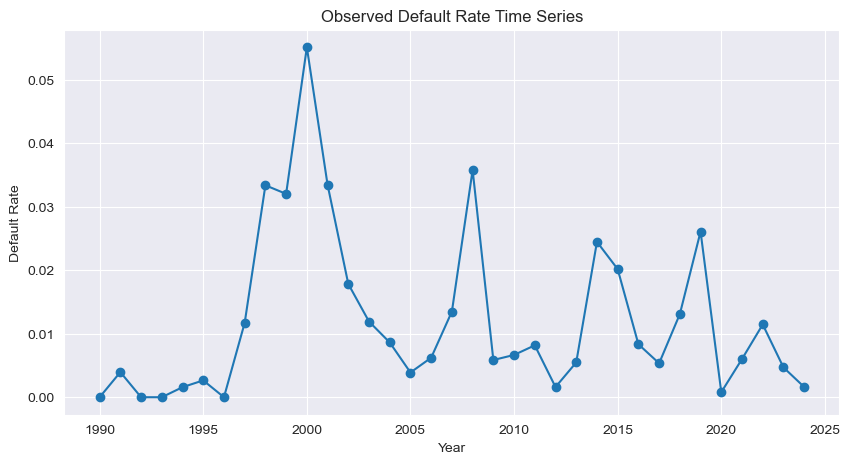

In [7]:
plt.figure()
plt.plot(years, obs, marker="o")
plt.title("Observed Default Rate Time Series")
plt.xlabel("Year")
plt.ylabel("Default Rate")
plt.grid(True)
plt.show()

In [11]:
#step2
def vasicek_sim(PD, rho, n_loans=10000, n_sim=10000, random_state=None):

    rng = np.random.default_rng(random_state)

    # Systematic (macro) factor: one per scenario
    Z = rng.normal(size=n_sim)

    # Idiosyncratic shocks: one per loan and scenario
    eps = rng.normal(size=(n_sim, n_loans))

    # Latent variables: X = sqrt(rho)*Z + sqrt(1-rho)*eps
    X = np.sqrt(rho) * Z[:, None] + np.sqrt(1 - rho) * eps

    # Default threshold corresponding to the unconditional PD
    threshold = norm.ppf(PD)

    # Default indicator: X < threshold
    default_rate = (X < threshold).mean(axis=1)

    return default_rate

In [12]:
corr_list = [0.0, 0.1, 0.2, 0.3, 0.5]
rows = []

for rho in corr_list:
    sim_rates = vasicek_sim(mean_obs, rho, n_loans=10000, n_sim=10000, random_state=42)
    mean_sim = np.mean(sim_rates)
    std_sim = np.std(sim_rates, ddof=1)
    rows.append((rho, mean_sim, std_sim))

result_corr = pd.DataFrame(rows, columns=["rho", "mean_sim", "std_sim"])
result_corr

,rho,mean_sim,std_sim
0,0.0,0.012028,0.001095
1,0.1,0.012184,0.011542
2,0.2,0.012285,0.018517
3,0.3,0.012381,0.025594
4,0.5,0.012589,0.041030


In [14]:
result_corr["std_diff"] = np.abs(result_corr["std_sim"] - std_obs)
best_row = result_corr.loc[result_corr["std_diff"].idxmin()]
rho_best = best_row["rho"]

print("Observed std:", std_obs)
print(result_corr)
print("\nBest fitting correlation rho* =", rho_best)

Observed std: 0.013011569492983625
   rho  mean_sim   std_sim  std_diff
0  0.0  0.012028  0.001095  0.011917
1  0.1  0.012184  0.011542  0.001470
2  0.2  0.012285  0.018517  0.005505
3  0.3  0.012381  0.025594  0.012582
4  0.5  0.012589  0.041030  0.028018

Best fitting correlation rho* = 0.1


In [ ]:
#Yes. The simulation with correlation ρ = 0.1 best matches the observed time series, particularly in terms of standard deviation.

In [ ]:
#step3

In [15]:
def simulate_time_series(pd, rho, T, exposures=10000, random_state=None):
    rng = np.random.default_rng(random_state)
    series = np.zeros(T)
    threshold = norm.ppf(pd)

    for t in range(T):
        # One macro shock per time step
        rm = rng.normal()
        # Idiosyncratic shocks for all loans
        ei = rng.normal(size=exposures)
        # Latent variable
        X = np.sqrt(rho) * rm + np.sqrt(1 - rho) * ei
        # Portfolio default rate at time t
        series[t] = np.mean(X < threshold)

    return series


In [16]:
T = len(obs)
PD = mean_obs
rho_best = 0.1

sim1 = simulate_time_series(PD, rho_best, T, random_state=1)
sim2 = simulate_time_series(PD, rho_best, T, random_state=2)
sim3 = simulate_time_series(PD, rho_best, T, random_state=3)


In [17]:
def summary_stats(x):
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "p95": np.percentile(x, 95),
        "p99": np.percentile(x, 99)
    }

stats_df = pd.DataFrame(
    [
        summary_stats(obs),
        summary_stats(sim1),
        summary_stats(sim2),
        summary_stats(sim3)
    ],
    index=["Observed", "Sim1", "Sim2", "Sim3"]
)

stats_df


,mean,median,p95,p99
Observed,0.012038,0.006656,0.034141,0.048528
Sim1,0.011537,0.010500,0.023060,0.031596
Sim2,0.012680,0.010900,0.032830,0.036940
Sim3,0.013646,0.011800,0.030960,0.045452


In [ ]:
#They are close to the observed series in overall level, but the simulated tails are generally slightly lower than the historical extremes.
#The three simulated series look similar in average level and volatility, but differ in the timing and height of their spikes due to randomness.

In [22]:
sim_full = vasicek_sim(
    PD,
    rho_best,
    n_loans=10000,
    n_sim=50000,
    random_state=999
)

VaR_99 = np.percentile(sim_full, 99)
print(VaR_99)

0.0543


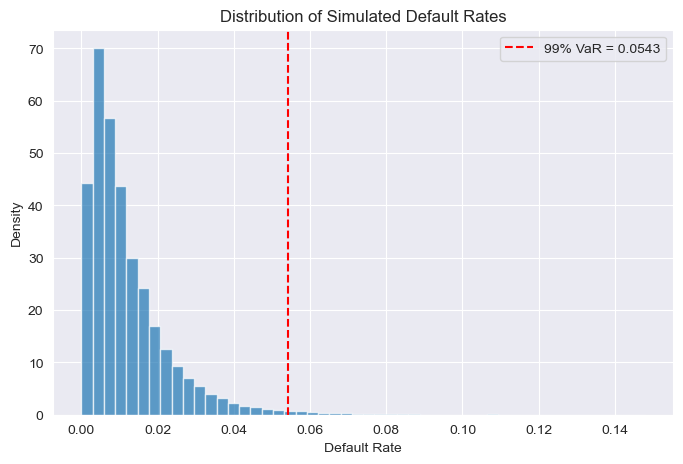

In [23]:
plt.figure(figsize=(8,5))
plt.hist(sim_full, bins=50, density=True, alpha=0.7)
plt.axvline(VaR_99, color="red", linestyle="--", label=f"99% VaR = {VaR_99:.4f}")
plt.title("Distribution of Simulated Default Rates")
plt.xlabel("Default Rate")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#The 99% VaR is higher than the worst default rate in the observed series and also higher than the worst values in all three simulated time series. This indicates that the model predicts more extreme tail outcomes than those actually observed.